In [23]:
from dotenv import load_dotenv
import os
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI

load_dotenv()

True

In [24]:
# llm = ChatGroq(model="deepseek-r1-distill-llama-70b")
llm = ChatOpenAI(model="gpt-4o")

In [25]:
llm.invoke("What is the capital of France?")  # Example usage

AIMessage(content='The capital of France is Paris.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 7, 'prompt_tokens': 14, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-ByNK0NxB1TaBMTnfcrRJJYtHUHnMg', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--bac95a5f-b5ff-4ebe-9c81-fe280bb10352-0', usage_metadata={'input_tokens': 14, 'output_tokens': 7, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [26]:
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
tavily_search = TavilySearchResults(api_key=TAVILY_API_KEY)

In [27]:
tavily_search.invoke("What is the capital of France?")  # Example usage

[{'title': 'List of capitals of France - Wikipedia',
  'url': 'https://en.wikipedia.org/wiki/List_of_capitals_of_France',
  'content': 'This is a chronological list of capitals of France. The capital of France has been Paris since its liberation in 1944.\n\n## Chronology\n\n[edit] [...] - Tours (10–13 June 1940), the city served as the temporary capital of France during World War II after the government fled Paris due to the German advance.\n- Bordeaux (June 1940), the government was relocated from Paris to Tours then Bordeaux very briefly during World War II, when it became apparent that Paris would soon fall into German hands. [...] - Paris (1789–1871), on 5 and 6 October 1789, a throng from Paris invaded the castle and forced the royal family to move back to Paris. The National Constituent Assembly "National Constituent Assembly (France)") followed the King to Paris soon afterward; Versailles lost its role of capital city.',
  'score': 0.8993429},
 {'title': 'Paris facts: the capita

In [28]:
code = """
x = 10
y = 20
print(f"The sum of x and y is {x + y}")
"""

In [29]:
from langchain_experimental.utilities import PythonREPL
python_repl = PythonREPL()
python_repl.run(code)  # Example usage

'The sum of x and y is 30\n'

In [30]:
from langchain.tools import tool
from typing import Annotated

@tool
def python_repl_tool(code: Annotated[str, "The python code to execute to generate your chart"]) -> str:
    """
    Use this to execute python code and do math. If you want to see the output of a value,
    you should print it out with 'print(...)'. This is visible to the user.
    """
    try:
        result = python_repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    
    result_str = f"Successfully executed:\n\'\'\'python\n\'\'\'\nStdout: {result}"
    return result_str

In [31]:
members = ["researcher", "coder"]
options = members + ["FINISH"]
print(members)
print(options)

['researcher', 'coder']
['researcher', 'coder', 'FINISH']


In [32]:
from typing import Literal
from typing_extensions import TypedDict


In [33]:
class Router(TypedDict):
    next: Literal["researcher", "coder", "FINISH"]

In [34]:
from langgraph.graph import MessagesState, StateGraph, START, END

class State(MessagesState):
    next: str

In [35]:
system_prompt = f"""
You are a supervisor, tasked with managing a conversation between the following workers: {members}.
Given the following user request, respond with the worker to act next.
Each worker will perform a task and respond with their results and status.
When finished, respond with FINISH.
"""

In [36]:
from langgraph.types import Command
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import AIMessage, HumanMessage

In [37]:
def supervisor_agent(state: State) -> Command[Literal["researcher", "coder", "__end__"]]:
    messages = [{"role": "system", "content": system_prompt},] + state["messages"]

    llm_with_structured_output = llm.with_structured_output(Router)
    resp = llm_with_structured_output.invoke(messages)

    next_worker = resp["next"]

    print("*************Below is my GoTo**************")
    print(next_worker)

    if next_worker == "FINISH":
        next_worker = END

    return Command(goto=next_worker, update={"next":next_worker})



In [38]:
def researcher_node(state: State) -> Command[Literal["supervisor"]]:
    researcher_agent = create_react_agent(llm, 
                       tools=[tavily_search],
                       prompt = "You are a researcher. DO NOT do any math.")
    
    result = researcher_agent.invoke(state)

    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="researcher"),
            ]
        },
        goto="supervisor"
    )

In [39]:
def coder_node(state: State) -> Command[Literal["supervisor"]]:
    coder_agent = create_react_agent(
        llm,
        tools=[python_repl_tool],
        prompt="You are a coder. DO NOT do any research.",
    )

    result = coder_agent.invoke(state)

    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="coder"),
            ]
        },
        goto="supervisor"
    )

In [40]:
graph = StateGraph(State)

In [41]:
graph.add_node("supervisor", supervisor_agent)
graph.add_node("researcher", researcher_node)
graph.add_node("coder", coder_node)

graph.add_edge(START, "supervisor")

In [42]:
app = graph.compile()

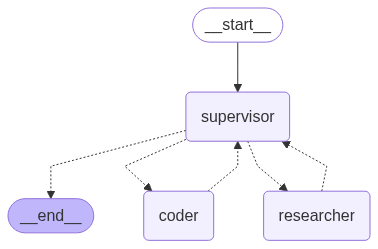

In [43]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [44]:
for s in app.stream({"messages": [("user", "What's the square root of 42?")]}, subgraphs = True):
    print(s)
    print("**********BELOW IS MY STATE**********")


*************Below is my GoTo**************
coder
((), {'supervisor': {'next': 'coder'}})
**********BELOW IS MY STATE**********
(('coder:f58c1c9f-d748-1b12-7ea8-69c35777f621',), {'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_cu1rj89XHtJ34KV9Qd7pgJj3', 'function': {'arguments': '{"code":"import math\\nmath.sqrt(42)"}', 'name': 'python_repl_tool'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 107, 'total_tokens': 130, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-ByNKVnkICF7aVScYkql5pDttrfO3P', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--cd8dd486-0003-43f2-abd0-a10801d398bb-0', tool_ca